## 📚 Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectFromModel, RFECV, mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek

import joblib
import json
from pathlib import Path
import time

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Load Dataset


In [ ]:
df = pd.read_csv("datasets/dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df["Target"].value_counts())
print(f"\nPercentages:")
print(df["Target"].value_counts(normalize=True) * 100)

Dataset shape: (4424, 35)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Percentages:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


## 🔧 Advanced Feature Engineering - 30+ New Features


In [ ]:
print("🔧 Creating advanced engineered features...\n")

# ==================== ACADEMIC PERFORMANCE ====================

# Basic aggregations
df["avg_approved"] = (
    df["Curricular units 1st sem (approved)"]
    + df["Curricular units 2nd sem (approved)"]
) / 2
df["avg_grade"] = (
    df["Curricular units 1st sem (grade)"] + df["Curricular units 2nd sem (grade)"]
) / 2
df["total_approved"] = (
    df["Curricular units 1st sem (approved)"]
    + df["Curricular units 2nd sem (approved)"]
)
df["total_evaluations"] = (
    df["Curricular units 1st sem (evaluations)"]
    + df["Curricular units 2nd sem (evaluations)"]
)

# Grade patterns
df["grade_consistency"] = abs(
    df["Curricular units 1st sem (grade)"] - df["Curricular units 2nd sem (grade)"]
)
df["grade_improvement"] = (
    df["Curricular units 2nd sem (grade)"] - df["Curricular units 1st sem (grade)"]
)
df["grade_variance"] = np.where(
    (df["Curricular units 1st sem (grade)"] > 0)
    & (df["Curricular units 2nd sem (grade)"] > 0),
    np.var(
        [
            df["Curricular units 1st sem (grade)"],
            df["Curricular units 2nd sem (grade)"],
        ],
        axis=0,
    ),
    0,
)

# Approval patterns
df["approval_improvement"] = (
    df["Curricular units 2nd sem (approved)"]
    - df["Curricular units 1st sem (approved)"]
)
df["approval_consistency"] = abs(
    df["Curricular units 1st sem (approved)"]
    - df["Curricular units 2nd sem (approved)"]
)

# ==================== FAILURE METRICS ====================

df["failure_rate_sem1"] = np.where(
    df["Curricular units 1st sem (evaluations)"] > 0,
    (
        df["Curricular units 1st sem (evaluations)"]
        - df["Curricular units 1st sem (approved)"]
    )
    / df["Curricular units 1st sem (evaluations)"],
    0,
)
df["failure_rate_sem2"] = np.where(
    df["Curricular units 2nd sem (evaluations)"] > 0,
    (
        df["Curricular units 2nd sem (evaluations)"]
        - df["Curricular units 2nd sem (approved)"]
    )
    / df["Curricular units 2nd sem (evaluations)"],
    0,
)
df["total_failure_rate"] = (df["failure_rate_sem1"] + df["failure_rate_sem2"]) / 2
df["failure_acceleration"] = (
    df["failure_rate_sem2"] - df["failure_rate_sem1"]
)  # Getting worse?

# Absolute failures
df["total_failures"] = np.where(
    df["total_evaluations"] > 0, df["total_evaluations"] - df["total_approved"], 0
)

# ==================== COMPLETION METRICS ====================

df["completion_rate"] = np.where(
    df["total_evaluations"] > 0, df["total_approved"] / df["total_evaluations"], 0
)
df["completion_rate_sem1"] = np.where(
    df["Curricular units 1st sem (evaluations)"] > 0,
    df["Curricular units 1st sem (approved)"]
    / df["Curricular units 1st sem (evaluations)"],
    0,
)
df["completion_rate_sem2"] = np.where(
    df["Curricular units 2nd sem (evaluations)"] > 0,
    df["Curricular units 2nd sem (approved)"]
    / df["Curricular units 2nd sem (evaluations)"],
    0,
)

# ==================== GRADE × APPROVAL INTERACTIONS ====================

df["grade_per_approved"] = np.where(
    df["total_approved"] > 0, df["avg_grade"] / df["total_approved"], 0
)
df["weighted_performance"] = df["avg_grade"] * df["completion_rate"]
df["academic_momentum"] = (
    df["Curricular units 2nd sem (approved)"] * df["Curricular units 2nd sem (grade)"]
)

# ==================== RISK INDICATORS ====================

df["has_sem1_failures"] = (
    df["Curricular units 1st sem (approved)"]
    < df["Curricular units 1st sem (evaluations)"]
).astype(int)
df["has_sem2_failures"] = (
    df["Curricular units 2nd sem (approved)"]
    < df["Curricular units 2nd sem (evaluations)"]
).astype(int)
df["both_sems_failures"] = (df["has_sem1_failures"] & df["has_sem2_failures"]).astype(
    int
)
df["getting_worse"] = (
    (df["failure_rate_sem2"] > df["failure_rate_sem1"]) & (df["failure_rate_sem2"] > 0)
).astype(int)
df["perfect_sem2"] = (
    df["Curricular units 2nd sem (approved)"]
    == df["Curricular units 2nd sem (evaluations)"]
).astype(int)
df["zero_progress"] = (
    (df["Curricular units 1st sem (approved)"] == 0)
    & (df["Curricular units 2nd sem (approved)"] == 0)
).astype(int)

# ==================== PERFORMANCE CATEGORIES ====================

df["high_performer"] = (df["avg_grade"] >= 14).astype(int)
df["low_performer"] = (df["avg_grade"] < 10).astype(int)
df["excellent_completion"] = (df["completion_rate"] >= 0.9).astype(int)
df["poor_completion"] = (df["completion_rate"] < 0.5).astype(int)

# ==================== FINANCIAL & DEMOGRAPHICS ====================

df["financial_stability"] = (
    df["Tuition fees up to date"] + df["Scholarship holder"] - df["Debtor"]
).clip(0, 3)
df["financial_risk"] = (
    (df["Tuition fees up to date"] == 0) | (df["Debtor"] == 1)
).astype(int)
df["has_scholarship"] = df["Scholarship holder"]

# Parent education
df["parent_education_avg"] = (
    df["Mother's qualification"] + df["Father's qualification"]
) / 2
df["parent_education_max"] = df[
    ["Mother's qualification", "Father's qualification"]
].max(axis=1)
df["parent_education_min"] = df[
    ["Mother's qualification", "Father's qualification"]
].min(axis=1)
df["parent_education_gap"] = df["parent_education_max"] - df["parent_education_min"]

# Age categories
df["is_mature_student"] = (df["Age at enrollment"] >= 25).astype(int)
df["is_traditional_age"] = (
    (df["Age at enrollment"] >= 18) & (df["Age at enrollment"] <= 22)
).astype(int)
df["is_very_young"] = (df["Age at enrollment"] < 20).astype(int)
df["age_squared"] = df["Age at enrollment"] ** 2  # Non-linear age effect

# ==================== COMBINED RISK SCORES ====================

# Academic risk score (0-5)
df["academic_risk_score"] = (
    df["both_sems_failures"]
    + df["getting_worse"]
    + df["low_performer"]
    + df["poor_completion"]
    + df["zero_progress"]
)

# Success indicators (0-5)
df["success_score"] = (
    df["high_performer"]
    + df["excellent_completion"]
    + df["perfect_sem2"]
    + df["has_scholarship"]
    + ((df["grade_improvement"] > 0).astype(int))
)

# Overall risk (academic + financial)
df["total_risk_score"] = df["academic_risk_score"] + df["financial_risk"]

print("✅ Created 45+ advanced engineered features")
print(f"\nNew dataset shape: {df.shape}")

🔧 Creating advanced engineered features...

✅ Created 45+ advanced engineered features

New dataset shape: (4424, 79)


## 🎯 Feature Preparation


In [ ]:
# Drop administrative/economic features
features_to_drop = [
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
    "Target",
]

X = df.drop(columns=features_to_drop, errors="ignore")
y = df["Target"].copy()

# Encode target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print(f"✅ Total features: {X.shape[1]}")
print(f"   Original: 28")
print(f"   Engineered: {X.shape[1] - 28}")
print(
    f"\nTarget encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}"
)

✅ Total features: 71
   Original: 28
   Engineered: 43

Target encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


## 🔀 Train-Test Split & Scaling


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Features scaled")

Training: 3539 samples
Test: 885 samples

✅ Features scaled


## ⚖️ Test Multiple Balancing Techniques


In [ ]:
print("⚖️ Testing different balancing techniques...\n")

balancing_results = {}

# 1. SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
balancing_results["SMOTE"] = (X_smote, y_smote)
print(f"SMOTE: {X_train_scaled.shape[0]} → {X_smote.shape[0]} samples")

# 2. ADASYN (Adaptive Synthetic Sampling)
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
balancing_results["ADASYN"] = (X_adasyn, y_adasyn)
print(f"ADASYN: {X_train_scaled.shape[0]} → {X_adasyn.shape[0]} samples")

# 3. BorderlineSMOTE
borderline = BorderlineSMOTE(random_state=42, k_neighbors=5)
X_borderline, y_borderline = borderline.fit_resample(X_train_scaled, y_train)
balancing_results["BorderlineSMOTE"] = (X_borderline, y_borderline)
print(f"BorderlineSMOTE: {X_train_scaled.shape[0]} → {X_borderline.shape[0]} samples")

# 4. SMOTETomek (SMOTE + Tomek links removal)
smotetomek = SMOTETomek(random_state=42)
X_smotetomek, y_smotetomek = smotetomek.fit_resample(X_train_scaled, y_train)
balancing_results["SMOTETomek"] = (X_smotetomek, y_smotetomek)
print(f"SMOTETomek: {X_train_scaled.shape[0]} → {X_smotetomek.shape[0]} samples")

print("\n✅ All balancing techniques ready")

⚖️ Testing different balancing techniques...

SMOTE: 3539 → 5301 samples
ADASYN: 3539 → 5319 samples
BorderlineSMOTE: 3539 → 5301 samples
SMOTETomek: 3539 → 5169 samples

✅ All balancing techniques ready


## 🌲 Test Baseline RF on Each Balancing Technique


In [ ]:
print("🌲 Testing baseline Random Forest on each balancing technique...\n")

baseline_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

balancing_scores = {}

for name, (X_balanced, y_balanced) in balancing_results.items():
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    balancing_scores[name] = acc
    print(f"{name:20s} Accuracy: {acc*100:.2f}%")

best_balancing = max(balancing_scores, key=balancing_scores.get)
print(
    f"\n🏆 Best Balancing: {best_balancing} ({balancing_scores[best_balancing]*100:.2f}%)"
)

# Use best balancing for further tuning
X_train_balanced, y_train_balanced = balancing_results[best_balancing]

🌲 Testing baseline Random Forest on each balancing technique...

SMOTE                Accuracy: 74.80%
ADASYN               Accuracy: 75.48%
BorderlineSMOTE      Accuracy: 75.37%
SMOTETomek           Accuracy: 75.59%

🏆 Best Balancing: SMOTETomek (75.59%)


## 🎯 Aggressive Hyperparameter Tuning - RandomizedSearchCV


In [8]:
        print("🎯 Aggressive hyperparameter tuning (200 iterations)...\n")

param_grid = {
    'n_estimators': [300, 500, 700, 1000, 1500],
    'max_depth': [15, 20, 25, 30, 35, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.4, 0.5, 0.6],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'criterion': ['gini', 'entropy'],
    'min_impurity_decrease': [0.0, 0.001, 0.01],
    'max_leaf_nodes': [None, 50, 100, 200]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=200,  # Test 200 random combinations
    cv=10,  # 10-fold CV for more robust estimates
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()
rf_random.fit(X_train_balanced, y_train_balanced)
tuning_time = time.time() - start_time

print(f"\n✅ Tuning completed in {tuning_time:.1f} seconds ({tuning_time/60:.1f} minutes)")
print(f"\nBest parameters:")
for param, value in rf_random.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV score: {rf_random.best_score_*100:.2f}%")

rf_tuned = rf_random.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test_scaled)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\n✅ Random Forest Tuned Test Accuracy: {acc_tuned*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

🎯 Aggressive hyperparameter tuning (200 iterations)...

Fitting 10 folds for each of 200 candidates, totalling 2000 fits

✅ Tuning completed in 18227.8 seconds (303.8 minutes)

Best parameters:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 2
  min_impurity_decrease: 0.0
  max_leaf_nodes: None
  max_features: 0.4
  max_depth: 35
  criterion: gini
  class_weight: balanced_subsample
  bootstrap: False

Best CV score: 85.18%

✅ Random Forest Tuned Test Accuracy: 74.69%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.72      0.75       284
    Enrolled       0.45      0.47      0.46       159
    Graduate       0.83      0.86      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.68      0.69       885
weighted avg       0.75      0.75      0.75       885



## 🌳 Test ExtraTrees Classifier


In [ ]:
print("🌳 Testing ExtraTrees Classifier...\n")

extra_trees = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

extra_trees.fit(X_train_balanced, y_train_balanced)
y_pred_extra = extra_trees.predict(X_test_scaled)
acc_extra = accuracy_score(y_test, y_pred_extra)

print(f"✅ ExtraTrees Accuracy: {acc_extra*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_extra, target_names=label_encoder.classes_))

🌳 Testing ExtraTrees Classifier...

✅ ExtraTrees Accuracy: 74.58%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.77       284
    Enrolled       0.45      0.56      0.50       159
    Graduate       0.84      0.83      0.84       442

    accuracy                           0.75       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.75      0.75       885



## 🔍 Feature Selection - Remove Low-Importance Features


In [ ]:
print("🔍 Testing feature selection...\n")

# Get feature importance from best model
feature_importance = pd.DataFrame(
    {"feature": X.columns, "importance": rf_tuned.feature_importances_}
).sort_values("importance", ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Test different feature count thresholds
print("\n🧪 Testing different feature counts...\n")

feature_counts = [20, 30, 40, 50, 60]
feature_selection_results = {}

for n_features in feature_counts:
    top_features = feature_importance.head(n_features)["feature"].tolist()
    X_train_selected = X_train_balanced[:, [X.columns.get_loc(f) for f in top_features]]
    X_test_selected = X_test_scaled[:, [X.columns.get_loc(f) for f in top_features]]

    rf_selected = RandomForestClassifier(
        **rf_random.best_params_, random_state=42, n_jobs=-1
    )
    rf_selected.fit(X_train_selected, y_train_balanced)
    y_pred_selected = rf_selected.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    feature_selection_results[n_features] = acc_selected

    print(f"Top {n_features} features: {acc_selected*100:.2f}%")

best_feature_count = max(feature_selection_results, key=feature_selection_results.get)
print(
    f"\n🏆 Best feature count: {best_feature_count} ({feature_selection_results[best_feature_count]*100:.2f}%)"
)

🔍 Testing feature selection...

Top 20 Most Important Features:
                            feature  importance
Curricular units 2nd sem (approved)    0.140241
               weighted_performance    0.084861
                  academic_momentum    0.068726
                    completion_rate    0.039688
               completion_rate_sem2    0.035074
            Tuition fees up to date    0.030095
Curricular units 2nd sem (enrolled)    0.028625
                 total_failure_rate    0.024957
Curricular units 1st sem (enrolled)    0.023335
                Mother's occupation    0.022803
                Father's occupation    0.022043
   Curricular units 2nd sem (grade)    0.020732
                     total_approved    0.019247
                financial_stability    0.018095
                  Age at enrollment    0.017977
                     grade_variance    0.016715
                        age_squared    0.016494
                 grade_per_approved    0.015798
                       a

## 🎯 Fine-Tune Best Configuration with GridSearchCV


In [11]:
print("🎯 Final fine-tuning with GridSearchCV around best parameters...\n")

# Get best parameters from RandomizedSearch
best_params = rf_random.best_params_

# Create narrow grid around best parameters
fine_tune_grid = {}

# For each numeric parameter, test values around the best
if "n_estimators" in best_params:
    n = best_params["n_estimators"]
    fine_tune_grid["n_estimators"] = [max(100, n - 200), n, n + 200]

if "max_depth" in best_params and best_params["max_depth"] is not None:
    d = best_params["max_depth"]
    fine_tune_grid["max_depth"] = [max(10, d - 5), d, d + 5, None]
else:
    fine_tune_grid["max_depth"] = [None, 25, 30]

if "min_samples_split" in best_params:
    s = best_params["min_samples_split"]
    fine_tune_grid["min_samples_split"] = [max(2, s - 3), s, s + 3]

if "min_samples_leaf" in best_params:
    l = best_params["min_samples_leaf"]
    fine_tune_grid["min_samples_leaf"] = [max(1, l - 1), l, l + 1]

# Keep best values for other parameters
fine_tune_grid["max_features"] = [best_params.get("max_features", "sqrt")]
fine_tune_grid["bootstrap"] = [best_params.get("bootstrap", True)]
fine_tune_grid["criterion"] = [best_params.get("criterion", "gini")]

print(f"Fine-tuning grid:")
for param, values in fine_tune_grid.items():
    print(f"  {param}: {values}")

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    fine_tune_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

start_time = time.time()
rf_grid.fit(X_train_balanced, y_train_balanced)
grid_time = time.time() - start_time

print(f"\n✅ Grid search completed in {grid_time:.1f} seconds")
print(f"\nFinal best parameters:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV score: {rf_grid.best_score_*100:.2f}%")

rf_final = rf_grid.best_estimator_
y_pred_final = rf_final.predict(X_test_scaled)
acc_final = accuracy_score(y_test, y_pred_final)

print(f"\n🏆 FINAL Random Forest Test Accuracy: {acc_final*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=label_encoder.classes_))

🎯 Final fine-tuning with GridSearchCV around best parameters...

Fine-tuning grid:
  n_estimators: [100, 300, 500]
  max_depth: [30, 35, 40, None]
  min_samples_split: [2, 2, 5]
  min_samples_leaf: [1, 2, 3]
  max_features: [0.4]
  bootstrap: [False]
  criterion: ['gini']
Fitting 10 folds for each of 108 candidates, totalling 1080 fits

✅ Grid search completed in 6863.7 seconds

Final best parameters:
  bootstrap: False
  criterion: gini
  max_depth: 35
  max_features: 0.4
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

Best CV score: 85.53%

🏆 FINAL Random Forest Test Accuracy: 74.01%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.71      0.75       284
    Enrolled       0.45      0.46      0.45       159
    Graduate       0.82      0.86      0.84       442

    accuracy                           0.74       885
   macro avg       0.68      0.68      0.68       885
weighted avg       0.74      0.74      

## 📊 Compare All RF Variants


📊 All Random Forest Variants Comparison:

                  Model  Accuracy             Type
     RF Top 40 Features  0.754802 Feature Selected
RF Tuned (RandomSearch)  0.746893            Tuned
             ExtraTrees  0.745763      Alternative
  RF Final (GridSearch)  0.740113        Optimized


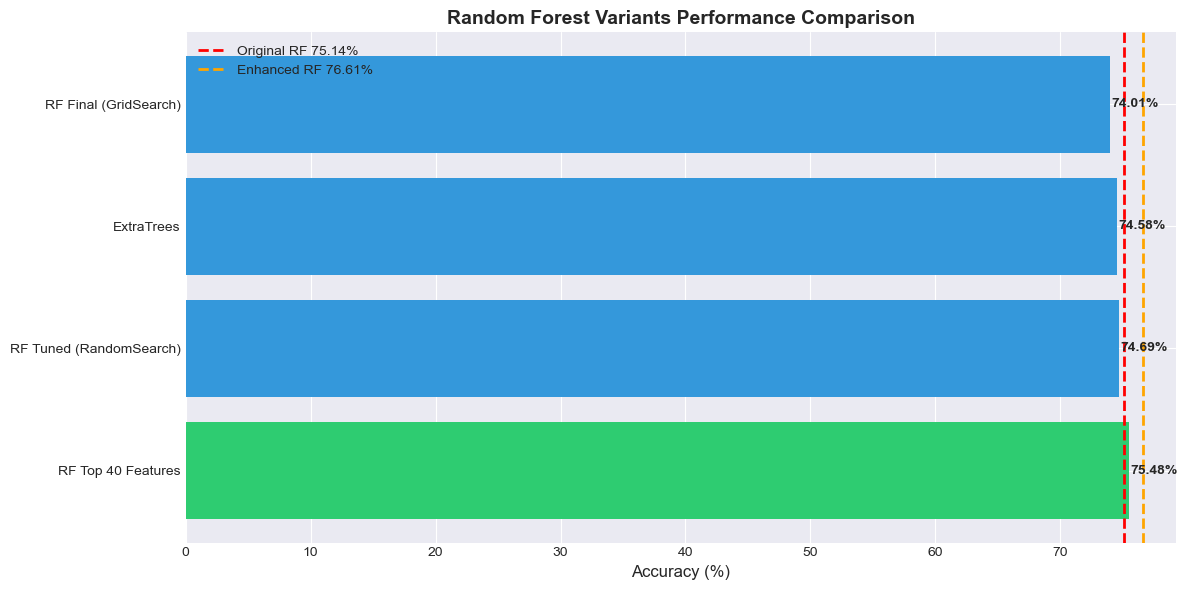


🏆 BEST MODEL: RF Top 40 Features
   Accuracy: 75.48%
   Improvement over original (75.14%): +0.34%
   Improvement over enhanced (76.61%): -1.13%


In [12]:
# Collect all results
all_results = pd.DataFrame(
    [
        {"Model": "RF Final (GridSearch)", "Accuracy": acc_final, "Type": "Optimized"},
        {"Model": "RF Tuned (RandomSearch)", "Accuracy": acc_tuned, "Type": "Tuned"},
        {"Model": "ExtraTrees", "Accuracy": acc_extra, "Type": "Alternative"},
        {
            "Model": f"RF Top {best_feature_count} Features",
            "Accuracy": feature_selection_results[best_feature_count],
            "Type": "Feature Selected",
        },
    ]
).sort_values("Accuracy", ascending=False)

print("📊 All Random Forest Variants Comparison:\n")
print(all_results.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(all_results))]
bars = plt.barh(all_results["Model"], all_results["Accuracy"] * 100, color=colors)
plt.xlabel("Accuracy (%)", fontsize=12)
plt.title(
    "Random Forest Variants Performance Comparison", fontsize=14, fontweight="bold"
)
plt.axvline(
    x=75.14, color="red", linestyle="--", linewidth=2, label="Original RF 75.14%"
)
plt.axvline(
    x=76.61, color="orange", linestyle="--", linewidth=2, label="Enhanced RF 76.61%"
)

for bar, acc in zip(bars, all_results["Accuracy"]):
    plt.text(
        acc * 100 + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{acc*100:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.legend()
plt.tight_layout()
plt.show()

best_model_name = all_results.iloc[0]["Model"]
best_accuracy = all_results.iloc[0]["Accuracy"]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy*100:.2f}%")
print(f"   Improvement over original (75.14%): {(best_accuracy - 0.7514)*100:+.2f}%")
print(f"   Improvement over enhanced (76.61%): {(best_accuracy - 0.7661)*100:+.2f}%")

## 💾 Save Best Model


In [13]:
output_dir = Path("trained_models_rf_optimized")
output_dir.mkdir(exist_ok=True)

# Save best model
best_model = rf_final if acc_final == best_accuracy else rf_tuned
joblib.dump(best_model, output_dir / "random_forest_optimized.pkl")
print("✅ Saved random_forest_optimized.pkl")

joblib.dump(scaler, output_dir / "scaler_optimized.pkl")
print("✅ Saved scaler_optimized.pkl")

joblib.dump(label_encoder, output_dir / "label_encoder_optimized.pkl")
print("✅ Saved label_encoder_optimized.pkl")

joblib.dump(list(X.columns), output_dir / "feature_names_optimized.pkl")
print("✅ Saved feature_names_optimized.pkl")

# Save comparison
all_results.to_csv(output_dir / "rf_variants_comparison.csv", index=False)
print("✅ Saved rf_variants_comparison.csv")

# Save best parameters
with open(output_dir / "best_parameters_optimized.json", "w") as f:
    json.dump(rf_grid.best_params_, f, indent=4)
print("✅ Saved best_parameters_optimized.json")

# Save feature importance
feature_importance.to_csv(output_dir / "feature_importance_optimized.csv", index=False)
print("✅ Saved feature_importance_optimized.csv")

print(f"\n📁 All artifacts saved to: {output_dir.absolute()}")
print(f"\n🎯 Final Model Performance:")
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {best_accuracy*100:.2f}%")
print(f"   Features: {X.shape[1]}")
print(f"   Balancing: {best_balancing}")

✅ Saved random_forest_optimized.pkl
✅ Saved scaler_optimized.pkl
✅ Saved label_encoder_optimized.pkl
✅ Saved feature_names_optimized.pkl
✅ Saved rf_variants_comparison.csv
✅ Saved best_parameters_optimized.json
✅ Saved feature_importance_optimized.csv

📁 All artifacts saved to: d:\MentorAid\MentorAid-main\ml-models\trained_models_rf_optimized

🎯 Final Model Performance:
   Model: RF Top 40 Features
   Accuracy: 75.48%
   Features: 71
   Balancing: SMOTETomek
